## Training a Classifier

In [ ]:
!pip install -q datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/export_annotations.csv')

In [ ]:
df.head()

,thread_id,Majority Decision,country
0,DSiKM6WEVCz,Inside,usa
1,DRPukA1EQce,Inside,usa
2,DQMqoqgkR2s,Inside,usa
3,DUoC5HZEf9u,Inside,usa
4,DP6imYIEZla,Inside,usa


In [ ]:
# Filter Unsure (w/ caveat: We remove the most difficult images to judge from what the model sees)
df = df[df['Majority Decision']!= "Unsure"]

In [ ]:
print(len(df))

444


In [ ]:
df['image'] = df['thread_id'].apply(lambda x: f"/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/RAW/Posts/{x}.jpg")

In [ ]:
df['label'] = df['Majority Decision']

In [ ]:
df.head()

,thread_id,Majority Decision,country,image,label
0,DSiKM6WEVCz,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside
1,DRPukA1EQce,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside
2,DQMqoqgkR2s,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside
3,DUoC5HZEf9u,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside
4,DP6imYIEZla,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside


In [ ]:
import pandas as pd
from PIL import Image
from datasets import Dataset, load_dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import AutoImageProcessor
import numpy as np
import torch
from transformers import (
    TrainingArguments,
    Trainer,
    ViTForImageClassification,
    EvalPrediction,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from torchvision import transforms as tv_transforms
import random

##############################################################################
# 1) Load and preprocess dataset
##############################################################################
dataset_df = df[['image', 'label']].copy()

# Drop rows where 'label' is NaN, as train_test_split with stratify cannot handle them
dataset_df.dropna(subset=['label'], inplace=True)

# Perform a stratified split on the 'label' column
train_df, test_df = train_test_split(
    dataset_df,
    test_size=0.2,
    random_state=4542,
    stratify=dataset_df["label"]  # ensures label distribution is preserved
)

# Convert to Dataset objects
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Optionally wrap them in a DatasetDict
split_dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})


##############################################################################
# 3) Load images in the split datasets so that each sample['image'] is a PIL Image
#    before we do any oversampling (so augmentation has PIL Images to work on).
##############################################################################
def load_image(example):
    try:
        # Try to load and convert the image to RGB
        example['pil_image'] = Image.open(example['image']) #.convert('RGB')
    except Exception as e:
        print(f"Error loading image {example['image']}: {e}")
        # Return a placeholder or skip the entry
        example['pil_image'] = None
    return example


split_dataset['train'] = split_dataset['train'].map(load_image)
split_dataset['test'] = split_dataset['test'].map(load_image)
split_dataset['train'] = split_dataset['train'].filter(lambda x: x['pil_image'] is not None)



##############################################################################
# 5) Now re-package into DatasetDict (train & validation)
##############################################################################
our_dataset = DatasetDict({
    'train': split_dataset['train'],
    'validation': split_dataset['test']
})

Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Filter:   0%|          | 0/350 [00:00<?, ? examples/s]

In [ ]:
##############################################################################
# 6) Setup image processor and label mappings
##############################################################################
labels = our_dataset["train"]["label"]
label2id = {c: idx for idx, c in enumerate(sorted(set(labels)))}
id2label = {idx: c for c, idx in label2id.items()}

processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')

def transforms(batch):
    batch['image'] = [Image.open(path).convert('RGB') for path in batch['image']]
    inputs = processor(batch['image'], return_tensors='pt')
    inputs['labels'] = [label2id[y] for y in batch['label']]
    return inputs


processed_dataset = our_dataset.with_transform(transforms)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [ ]:
##############################################################################
# 7) Compute class weights based on the new training distribution
##############################################################################
# Extract labels before applying transformations
raw_labels = our_dataset["train"]["label"]
all_labels = [label2id[label] for label in raw_labels]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to('cuda')

In [ ]:
df['label'].value_counts()

,count
label,
Inside,211
Outside,122
NotApplicable,105


In [ ]:
%env WANDB_PROJECT=forschungssem-setting

env: WANDB_PROJECT=forschungssem-setting


In [ ]:
import wandb
import torch
from transformers import ViTForImageClassification
from transformers.modeling_outputs import SequenceClassifierOutput
import numpy as np # Ensure np is imported as compute_metrics uses it
from sklearn.metrics import accuracy_score, precision_recall_fscore_support # Ensure these are imported as compute_metrics uses them

##############################################################################
# 8) Define custom ViT model to handle class weights
##############################################################################
class CustomViTForImageClassification(ViTForImageClassification):
    def __init__(self, config, class_weights=None, **kwargs):
        super().__init__(config, **kwargs) # Pass kwargs to parent __init__
        # Store class_weights as an instance attribute
        self.class_weights = class_weights

    def forward(self, pixel_values=None, labels=None, **kwargs):
        outputs = super().forward(pixel_values=pixel_values, labels=labels, **kwargs)
        logits = outputs.logits

        if labels is not None:
            if self.class_weights is None:
                # Fallback to default behavior if weights not provided
                loss_fct = torch.nn.CrossEntropyLoss()
            else:
                loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits, labels)
            return SequenceClassifierOutput(
                loss=loss,
                logits=logits,
                hidden_states=outputs.hidden_states,
                attentions=outputs.attentions,
            )
        else:
            return outputs

num_labels = len(id2label)

# Step 1: Load the base model first to get its configuration and state_dict
base_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Step 2: Instantiate CustomViTForImageClassification with the base model's config and class_weights
model = CustomViTForImageClassification(
    config=base_model.config, # Pass the config from the loaded base model
    class_weights=class_weights # Pass custom class weights
)
# Step 3: Load the state_dict from the base model into the custom model
model.load_state_dict(base_model.state_dict(), strict=False)


##############################################################################
# 9) (Optional) Freeze the base model parameters except classifier head
##############################################################################
for name, param in model.named_parameters():
    if not name.startswith('classifier'):
        param.requires_grad = False

##############################################################################
# 10) Define our collate function
##############################################################################
def collate_fn(examples):
    pixel_values = torch.stack([ex["pixel_values"] for ex in examples])
    labels = torch.tensor([ex["labels"] for ex in examples], dtype=torch.long)
    return {'pixel_values': pixel_values, 'labels': labels}

##############################################################################
# 11) Training arguments
##############################################################################
training_args = TrainingArguments(
    output_dir="./cluster-model",
    per_device_train_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    num_train_epochs=6,
    report_to="wandb",
    run_name="vit-w/-sd-2",
    learning_rate=5e-3,
    weight_decay=0.01,
    save_total_limit=2,
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    lr_scheduler_type="cosine",
    warmup_steps=500,
)

##############################################################################
# 12) Define metrics
##############################################################################
def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

##############################################################################
# 13) Initialize the Trainer and train
##############################################################################
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=processed_dataset["train"],
    eval_dataset=processed_dataset["validation"]
)

trainer.train()
wandb.finish()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
wandb: WARNING Config item 'output_dir' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_train_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Con

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.180086,0.386364,0.405792,0.386364,0.393997
2,1.138657,1.027028,0.545455,0.549137,0.545455,0.547000
3,1.138657,0.827309,0.693182,0.700510,0.693182,0.695074
4,0.847739,0.639629,0.784091,0.792746,0.784091,0.786520
5,0.847739,0.505084,0.829545,0.833770,0.829545,0.831019
6,0.514892,0.412086,0.863636,0.864325,0.863636,0.863782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▁▂▄▆▇██
eval/f1,▁▂▄▆▇██
eval/loss,▇█▇▅▃▂▁
eval/precision,▁▂▄▆▇██
eval/recall,▁▂▄▆▇██
eval/runtime,▁▄▅▁█▁█
eval/samples_per_second,█▅▄█▁█▁
eval/steps_per_second,█▅▄█▁█▁
train/epoch,▁▁▂▂▄▅▅▇▇██
train/global_step,▁▁▂▂▄▅▅▇▇██
+3,...


## Use the Model

In [ ]:
import torch
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

def classify_image(image_path, model=model, processor=processor, id2label=id2label, top_k=3):
    """Classify an image and display results nicely in Jupyter."""

    # Load and process image
    image = Image.open(image_path).convert('RGB')
    inputs = processor(image, return_tensors='pt').to(model.device)

    # Inference
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]

    # Get top predictions
    top_probs, top_indices = probs.topk(min(top_k, len(id2label)))

    # Display results
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1.2]})

    # Show image
    axes[0].imshow(image)
    axes[0].axis('off')
    axes[0].set_title('Input Image', fontsize=12)

    # Show predictions as horizontal bar chart
    labels = [id2label[idx.item()] for idx in top_indices]
    scores = [p.item() * 100 for p in top_probs]
    colors = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(labels))]

    bars = axes[1].barh(labels[::-1], scores[::-1], color=colors[::-1])
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Prediction: {labels[0]}', fontsize=12, fontweight='bold')

    # Add percentage labels
    for bar, score in zip(bars, scores[::-1]):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{score:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return {'label': labels[0], 'confidence': scores[0], 'all_predictions': dict(zip(labels, scores))}

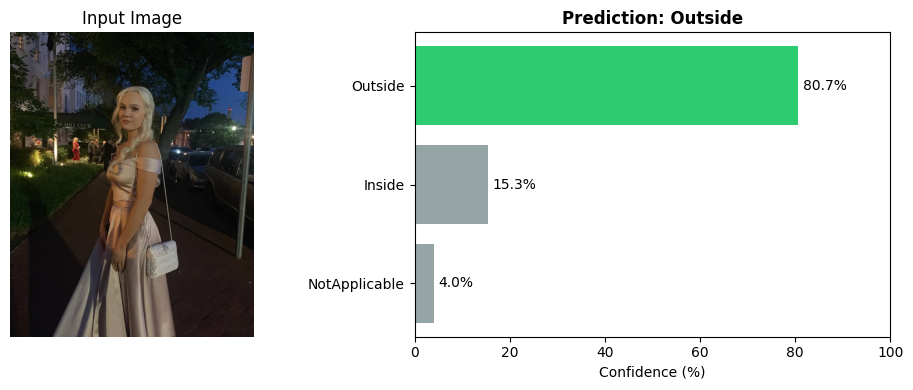

{'label': 'Outside',
 'confidence': 80.65342903137207,
 'all_predictions': {'Outside': 80.65342903137207,
  'Inside': 15.3256356716156,
  'NotApplicable': 4.020940139889717}}

In [ ]:
classify_image("/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/RAW/Posts/B_i69ZDDALG.jpg")

## Hyperparamter Tuning: Using W&B Sweeps

In [ ]:
import pandas as pd
import numpy as np
import torch
import wandb
from PIL import Image
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoImageProcessor,
    TrainingArguments,
    Trainer,
    ViTForImageClassification,
    EvalPrediction,
    EarlyStoppingCallback
)
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

###############################################################################
# Helper Functions & Classes
###############################################################################

def load_image(example):
    try:
        # Change 'path' to 'image'
        example['pil_image'] = Image.open(example['image'])
    except Exception as e:
        print(f"Error loading image {example['image']}: {e}")
        example['pil_image'] = None
    return example


def prepare_dataset(df):
    """Prepares dataset, computes label mappings and class weights."""
    # Change 'path' to 'image'
    dataset_df = df[['image', 'label']].copy()

    # Drop rows where 'label' is NaN, as train_test_split with stratify cannot handle them
    dataset_df.dropna(subset=['label'], inplace=True)

    train_df, test_df = train_test_split(
        dataset_df,
        test_size=0.2,
        random_state=4542,
        stratify=dataset_df["label"]
    )

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    split_dataset = DatasetDict({"train": train_dataset, "test": test_dataset})
    split_dataset['train'] = split_dataset['train'].map(load_image)
    split_dataset['test'] = split_dataset['test'].map(load_image)
    split_dataset['train'] = split_dataset['train'].filter(lambda x: x['pil_image'] is not None)

    our_dataset = DatasetDict({
        'train': split_dataset['train'],
        'validation': split_dataset['test']
    })

    # Label mappings
    labels = our_dataset["train"]["label"]
    label2id = {c: idx for idx, c in enumerate(sorted(set(labels)))}
    id2label = {idx: c for c, idx in label2id.items()}

    # Processor & transforms
    processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')

    def transforms(batch):
        # Change 'path' to 'image'
        batch['image'] = [Image.open(path).convert('RGB') for path in batch['image']]
        inputs = processor(batch['image'], return_tensors='pt')
        inputs['labels'] = [label2id[y] for y in batch['label']]
        return inputs

    processed_dataset = our_dataset.with_transform(transforms)

    # Class weights
    raw_labels = our_dataset["train"]["label"]
    all_labels = [label2id[label] for label in raw_labels]
    class_weights_np = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(all_labels),
        y=all_labels
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

    return processed_dataset, label2id, id2label, class_weights


class CustomViTForImageClassification(ViTForImageClassification):
    def forward(self, pixel_values=None, labels=None, **kwargs):
        outputs = super().forward(pixel_values=pixel_values, labels=labels)
        logits = outputs.logits
        if labels is not None:
            loss_fct = torch.nn.CrossEntropyLoss(
                weight=self.class_weights if hasattr(self, 'class_weights') else None
            )
            loss = loss_fct(logits, labels)
            return SequenceClassifierOutput(
                loss=loss, logits=logits,
                hidden_states=outputs.hidden_states,
                attentions=outputs.attentions,
            )
        return outputs


def collate_fn(examples):
    pixel_values = torch.stack([ex["pixel_values"] for ex in examples])
    labels = torch.tensor([ex["labels"] for ex in examples], dtype=torch.long)
    return {'pixel_values': pixel_values, 'labels': labels}


def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    # Weighted averages
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    # Per-class metrics
    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        labels, predictions, average=None
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision_w,
        "recall": recall_w,
        "f1": f1_w,
    }

    # Add per-class metrics using label names
    for idx, label_name in id2label.items():
        metrics[f"precision_{label_name}"] = precision_pc[idx]
        metrics[f"recall_{label_name}"] = recall_pc[idx]
        metrics[f"f1_{label_name}"] = f1_pc[idx]
        metrics[f"support_{label_name}"] = support_pc[idx]

    return metrics

In [ ]:
###############################################################################
# Prepare Dataset Once (Global)
###############################################################################
processed_dataset, label2id, id2label, class_weights = prepare_dataset(df)

###############################################################################
# Training Function for Sweep
###############################################################################
def train_and_evaluate(config=None):
    with wandb.init(config=config):
        config = wandb.config

        # Step 1: Load the base model first to get its configuration and state_dict
        base_model = ViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224',
            num_labels=len(label2id),
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True
        )

        # Step 2: Instantiate CustomViTForImageClassification with the base model's config and class_weights
        model = CustomViTForImageClassification(
            config=base_model.config, # Pass the config from the loaded base model
            class_weights=class_weights # Pass custom class weights
        )
        # Step 3: Load the state_dict from the base model into the custom model
        model.load_state_dict(base_model.state_dict(), strict=False)

        # Freeze base model
        for name, param in model.named_parameters():
            if not name.startswith('classifier'):
                param.requires_grad = False

        training_args = TrainingArguments(
            output_dir=config.output_dir,
            per_device_train_batch_size=config.batch_size,
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="steps",
            logging_steps=20,
            num_train_epochs=config.num_train_epochs,
            report_to="wandb",
            learning_rate=config.learning_rate,
            weight_decay=config.weight_decay,
            save_total_limit=2,
            remove_unused_columns=False,
            load_best_model_at_end=True,
            metric_for_best_model="f1",
            lr_scheduler_type=config.lr_scheduler_type,
            warmup_ratio=config.warmup_ratio,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            data_collator=collate_fn,
            compute_metrics=compute_metrics,
            train_dataset=processed_dataset["train"],
            eval_dataset=processed_dataset["validation"],
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
        )

        trainer.train()
        final_results = trainer.evaluate()
        wandb.log({"final_results": final_results})
        wandb.finish()

Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Filter:   0%|          | 0/350 [00:00<?, ? examples/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [ ]:
###############################################################################
# Sweep Configuration & Launch
###############################################################################
sweep_config = {
    "method": "bayes",
    "metric": {"name": "eval/f1", "goal": "maximize"},
    "parameters": {
        "num_train_epochs": {"values": [4, 6, 8]},
        "learning_rate": {"values": [1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0.0, 0.01, 0.05]},
        "batch_size": {"values": [16, 32, 64]},
        "warmup_ratio": {"values": [0.0, 0.05, 0.1]},
        "lr_scheduler_type": {"values": ["linear", "cosine"]},
        "output_dir": {"value": "./sweep-output"}
    }
}

sweep_id = wandb.sweep(sweep_config, project="forschungssem-setting")
wandb.agent(sweep_id, function=train_and_evaluate, count=20)  # run 20 trials

Create sweep with ID: git5ya6p
Sweep URL: https://wandb.ai/maximilian-auberger-regensburg/forschungssem-setting/sweeps/git5ya6p


wandb: Agent Starting Run: 2jbmcbao with config:
wandb: 	batch_size: 16
wandb: 	learning_rate: 0.001
wandb: 	lr_scheduler_type: linear
wandb: 	num_train_epochs: 4
wandb: 	output_dir: ./sweep-output
wandb: 	warmup_ratio: 0.05
wandb: 	weight_decay: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
wandb: WARNING Config item 'output_dir' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Confi

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.940743,0.469781,0.875000,0.875044,0.875000,0.874810
2,0.404265,0.331492,0.852273,0.853100,0.852273,0.852158
3,0.272032,0.304234,0.852273,0.853100,0.852273,0.852158
4,0.223532,0.297388,0.852273,0.853100,0.852273,0.852158


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▃▁█▃▃▃█
eval/f1,▄▁█▃▃▃█
eval/loss,▁▅▂▄▇█▂
eval/precision,▄▁█▃▄▄█
eval/recall,▃▁█▃▃▃█
eval/runtime,▁▇▆▁█▃▂
eval/samples_per_second,█▂▂▇▁▆▆
eval/steps_per_second,█▂▂▇▁▆▆
train/epoch,▁▂▄▄▅▇███
train/global_step,▁▂▄▄▅▇████
+3,...


## 5-Fold Validation Best Model

In [ ]:
from sklearn.model_selection import StratifiedKFold

def cross_validate_best_model(
    run_id: str,
    df: pd.DataFrame,
    project: str = "forschungssem-setting",
    n_folds: int = 5,
    epochs: int = -1,
    save_models: bool = False,
    save_path: str = "./cv-models"
):
    """
    Perform k-fold cross-validation using hyperparameters from a W&B run.

    Args:
        run_id: W&B run ID with best hyperparameters
        df: DataFrame with 'path' and 'label' columns
        project: W&B project name
        n_folds: Number of CV folds
        save_models: Whether to save each fold's model
        save_path: Base path for saving models
    """
    # Fetch config and best epoch from W&B
    api = wandb.Api()
    run = api.run(f"{project}/{run_id}")
    config = run.config

    if epochs > 0:
        best_epoch = epochs
    else:
      # best_epoch = get_best_epoch(run, metric="eval/f1") or config["num_train_epochs"] # get_best_epoch not defined
      best_epoch = config["num_train_epochs"]

    print(f"Running {n_folds}-fold CV with config from run {run_id}")
    print(f"Training each fold for {best_epoch} epochs\n")

    # Prepare data
    # Changed 'path' to 'image'
    dataset_df = df[['image', 'label']].copy()
    # Drop rows where 'label' is NaN to prevent TypeError during sorted(unique_labels)
    dataset_df.dropna(subset=['label'], inplace=True)
    labels = dataset_df['label'].values

    # Setup label mappings (consistent across folds)
    unique_labels = sorted(dataset_df['label'].unique())
    label2id = {c: idx for idx, c in enumerate(unique_labels)}
    id2label = {idx: c for c, idx in label2id.items()}

    processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')

    def transforms(batch):
        # Changed 'path' to 'image'
        batch['image'] = [Image.open(path).convert('RGB') for path in batch['image']]
        inputs = processor(batch['image'], return_tensors='pt')
        inputs['labels'] = [label2id[y] for y in batch['label']]
        return inputs

    # Initialize CV
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_metrics = []

    # Initialize W&B run for CV
    wandb.init(
        project=project,
        name=f"cv-{n_folds}fold-from-{run_id}",
        config={**config, "best_epoch": best_epoch, "n_folds": n_folds},
        tags=["cross-validation"]
    )

    for fold, (train_idx, val_idx) in enumerate(skf.split(dataset_df, labels)):
        print(f"\n{'='*50}")
        print(f"FOLD {fold + 1}/{n_folds}")
        print(f"{'='*50}")

        # Split data
        train_df = dataset_df.iloc[train_idx]
        val_df = dataset_df.iloc[val_idx]

        train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
        val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

        # Load images and filter failures
        # Changed 'path' to 'image' in load_image function definition
        def load_image_for_cv(example):
            try:
                example['pil_image'] = Image.open(example['image'])
            except Exception as e:
                print(f"Error loading image {example['image']}: {e}")
                example['pil_image'] = None
            return example

        train_dataset = train_dataset.map(load_image_for_cv)
        val_dataset = val_dataset.map(load_image_for_cv)
        train_dataset = train_dataset.filter(lambda x: x['pil_image'] is not None)
        val_dataset = val_dataset.filter(lambda x: x['pil_image'] is not None)

        fold_dataset = DatasetDict({
            'train': train_dataset,
            'validation': val_dataset
        }).with_transform(transforms)

        # Compute class weights for this fold
        fold_labels = [label2id[l] for l in train_df['label']]
        class_weights_np = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(fold_labels),
            y=fold_labels
        )
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        fold_class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

        # Step 1: Load the base model first to get its configuration and state_dict
        base_model = ViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224',
            num_labels=len(label2id),
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True
        )

        # Step 2: Instantiate CustomViTForImageClassification with the base model's config and class_weights
        model = CustomViTForImageClassification(
            config=base_model.config, # Pass the config from the loaded base model
            class_weights=fold_class_weights # Pass custom class weights
        )
        # Step 3: Load the state_dict from the base model into the custom model
        model.load_state_dict(base_model.state_dict(), strict=False)

        for name, param in model.named_parameters():
            if not name.startswith('classifier'):
                param.requires_grad = False

        fold_output_dir = f"{save_path}/fold-{fold + 1}" if save_models else f"./tmp-fold-{fold + 1}"

        training_args = TrainingArguments(
            output_dir=fold_output_dir,
            per_device_train_batch_size=config["batch_size"],
            eval_strategy="epoch",
            save_strategy="epoch" if save_models else "no",
            logging_strategy="steps",
            logging_steps=20,
            num_train_epochs=best_epoch,
            report_to="none",  # We'll log manually
            learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"],
            save_total_limit=1,
            remove_unused_columns=False,
            load_best_model_at_end=False,
            lr_scheduler_type=config["lr_scheduler_type"],
            warmup_ratio=config["warmup_ratio"],
        )

        # Create compute_metrics with access to id2label
        def compute_metrics_cv(eval_pred: EvalPrediction):
            logits, labels = eval_pred.predictions, eval_pred.label_ids
            predictions = np.argmax(logits, axis=1)

            accuracy = accuracy_score(labels, predictions)
            precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
                labels, predictions, average='weighted'
            )
            precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
                labels, predictions, average=None
            )

            metrics = {
                "accuracy": accuracy,
                "precision": precision_w,
                "recall": recall_w,
                "f1": f1_w,
            }

            for idx, label_name in id2label.items():
                metrics[f"precision_{label_name}"] = precision_pc[idx]
                metrics[f"recall_{label_name}"] = recall_pc[idx]
                metrics[f"f1_{label_name}"] = f1_pc[idx]
                metrics[f"support_{label_name}"] = support_pc[idx]

            return metrics

        trainer = Trainer(
            model=model,
            args=training_args,
            data_collator=collate_fn,
            compute_metrics=compute_metrics_cv,
            train_dataset=fold_dataset["train"],
            eval_dataset=fold_dataset["validation"],
        )

        trainer.train()
        fold_results = trainer.evaluate()

        # Log fold results
        fold_log = {f"fold_{fold + 1}/{k.replace('eval_', '')}": v
                    for k, v in fold_results.items()}
        wandb.log(fold_log)

        fold_metrics.append(fold_results)

        print(f"Fold {fold + 1} Results:")
        print(f"  F1: {fold_results['eval_f1']:.4f}")
        print(f"  Accuracy: {fold_results['eval_accuracy']:.4f}")

        # Cleanup if not saving
        if not save_models:
            import shutil
            shutil.rmtree(fold_output_dir, ignore_errors=True)

    # Aggregate metrics
    print(f"\n{'='*50}")
    print("CROSS-VALIDATION SUMMARY")
    print(f"{'='*50}")

    summary = {}
    metric_keys = [k.replace('eval_', '') for k in ['f1', 'accuracy', 'precision', 'recall']]

    for metric in metric_keys:
        values = [fm[f"eval_{metric}"] for fm in fold_metrics]
        mean_val = np.mean(values)
        std_val = np.std(values)
        summary[f"cv_mean_{metric}"] = mean_val
        summary[f"cv_std_{metric}"] = std_val

        if metric in ['f1', 'accuracy', 'precision', 'recall']:
            print(f"{metric}: {mean_val:.4f} \u00B1 {std_val:.4f}")

    # Log summary
    wandb.log(summary)

    # Create summary table
    summary_table = wandb.Table(
        columns=["Fold", "F1", "Accuracy", "Precision", "Recall"],
        data=[
            [f"Fold {i+1}",
             fm['eval_f1'],
             fm['eval_accuracy'],
             fm['eval_precision'],
             fm['eval_recall']]
            for i, fm in enumerate(fold_metrics)
        ] + [
            ["Mean \u00B1 Std",
             # Pass numeric values for F1, Accuracy, etc., not formatted strings
             summary['cv_mean_f1'],
             summary['cv_mean_accuracy'],
             summary['cv_mean_precision'],
             summary['cv_mean_recall']]
        ]
    )
    wandb.log({"cv_summary_table": summary_table})

    wandb.finish()

    return fold_metrics, summary

In [ ]:
fold_metrics, summary = cross_validate_best_model(
    run_id="dxqh4ar2",
    df=df,
    n_folds=5,
    epochs=2,
    save_models=False,
)

Running 5-fold CV with config from run dxqh4ar2
Training each fold for 2 epochs



Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


cv_mean_accuracy,▁
cv_mean_f1,▁
cv_mean_precision,▁
cv_mean_recall,▁
cv_std_accuracy,▁
cv_std_f1,▁
cv_std_precision,▁
cv_std_recall,▁
fold_1/accuracy,▁
fold_1/epoch,▁
+103,...



FOLD 1/5


Map:   0%|          | 0/350 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Precision Inside,Recall Inside,F1 Inside,Support Inside,Precision Notapplicable,Recall Notapplicable,F1 Notapplicable,Support Notapplicable,Precision Outside,Recall Outside,F1 Outside,Support Outside
1,No log,0.360236,0.839080,0.848652,0.839080,0.840830,0.923077,0.857143,0.888889,42,0.842105,0.761905,0.800000,21,0.724138,0.875000,0.792453,24
2,No log,0.331259,0.896552,0.901488,0.896552,0.896252,0.947368,0.857143,0.900000,42,0.840000,1.000000,0.913043,21,0.875000,0.875000,0.875000,24


Fold 5 Results:
  F1: 0.8963
  Accuracy: 0.8966

CROSS-VALIDATION SUMMARY
f1: 0.8817 ± 0.0504
accuracy: 0.8811 ± 0.0512
precision: 0.8854 ± 0.0484
recall: 0.8811 ± 0.0512


cv_mean_accuracy,▁
cv_mean_f1,▁
cv_mean_precision,▁
cv_mean_recall,▁
cv_std_accuracy,▁
cv_std_f1,▁
cv_std_precision,▁
cv_std_recall,▁
fold_1/accuracy,▁
fold_1/epoch,▁
+103,...


## Train Best Model

In [ ]:
def train_best_model(run_id: str, project: str = "forschungssem-setting", save_path: str = "./best-model", epochs: int = -1):
    """
    Train a model using hyperparameters from a specific W&B run,
    including the optimal number of epochs.
    """
    # Fetch run from W&B
    api = wandb.Api()
    run = api.run(f"{project}/{run_id}")
    config = run.config

    # Get the epoch with best F1
    if epochs < 0:
        # best_epoch = get_best_epoch(run, metric="eval/f1") or config["num_train_epochs"] # get_best_epoch not defined
        best_epoch = config["num_train_epochs"]
        print(f"Using config value for Epochs: {best_epoch}")

    else:
        best_epoch = epochs

    print(f"\nRetrieved config from run {run_id}:")
    for k, v in config.items():
        print(f"  {k}: {v}")
    print(f"  best_epoch: {best_epoch}")

    # Initialize a new run for tracking
    wandb.init(
        project=project,
        name=f"best-model-from-{run_id}",
        config={**config, "best_epoch": best_epoch},
        tags=["best-model", "final-training"]
    )

    # Step 1: Load the base model first to get its configuration and state_dict
    base_model = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224',
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # Step 2: Instantiate CustomViTForImageClassification with the base model's config and class_weights
    model = CustomViTForImageClassification(
        config=base_model.config, # Pass the config from the loaded base model
        class_weights=class_weights # Pass custom class weights
    )
    # Step 3: Load the state_dict from the base model into the custom model
    model.load_state_dict(base_model.state_dict(), strict=False)

    for name, param in model.named_parameters():
        if not name.startswith('classifier'):
            param.requires_grad = False

    training_args = TrainingArguments(
        output_dir=save_path,
        per_device_train_batch_size=config["batch_size"],
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=20,
        num_train_epochs=best_epoch,  # Use optimal epoch count
        report_to="wandb",
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        save_total_limit=2,
        remove_unused_columns=False,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        lr_scheduler_type=config["lr_scheduler_type"],
        warmup_ratio=config["warmup_ratio"],
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
        train_dataset=processed_dataset["train"],
        eval_dataset=processed_dataset["validation"],
    )

    trainer.train()
    final_results = trainer.evaluate()

    trainer.save_model(save_path)
    print(f"Model saved to {save_path}")

    wandb.log({"final_results": final_results})
    wandb.finish()

    return trainer, final_results

In [ ]:
trainer, results = train_best_model("dxqh4ar2", epochs=2)


Retrieved config from run dxqh4ar2:
  bf16: False
  fp16: False
  fsdp: []
  seed: 42
  tf32: None
  debug: []
  dtype: float32
  optim: adamw_torch_fused
  do_eval: True
  n_folds: 5
  project: huggingface
  use_cpu: False
  do_train: False
  id2label: {'0': 'Inside', '1': 'NotApplicable', '2': 'Outside'}
  label2id: {'Inside': 0, 'Outside': 2, 'NotApplicable': 1}
  qkv_bias: True
  run_name: None
  data_seed: None
  deepspeed: None
  hub_token: <HUB_TOKEN>
  log_level: passive
  max_steps: -1
  report_to: ['wandb']
  use_cache: False
  adam_beta1: 0.9
  adam_beta2: 0.999
  batch_size: 64
  best_epoch: 2
  do_predict: False
  eval_delay: 0
  eval_steps: None
  hidden_act: gelu
  image_size: 224
  local_rank: -1
  model_type: vit
  optim_args: None
  output_dir: ./sweep-output
  patch_size: 16
  pooler_act: tanh
  save_steps: 500
  ddp_backend: None
  ddp_timeout: 1800
  fsdp_config: {'xla': False, 'xla_fsdp_v2': False, 'min_num_params': 0, 'xla_fsdp_grad_ckpt': False}
  hidden_size: 

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
wandb: WARNING Config item 'output_dir' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Confi

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.302654,0.886364,0.887338,0.886364,0.885970
2,No log,0.368539,0.875000,0.877300,0.875000,0.874192


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./best-model


eval/accuracy,█▁█
eval/f1,█▁█
eval/loss,▁█▁
eval/precision,█▁█
eval/recall,█▁█
eval/runtime,▄▁█
eval/samples_per_second,▄█▁
eval/steps_per_second,▄█▁
train/epoch,▁███
train/global_step,▁████
eval/accuracy,0.88636


In [ ]:
# -----------------------------------------------------------------------------
# STEP 1: Save the model locally
# -----------------------------------------------------------------------------
# This creates a directory containing:
#   - pytorch_model.bin (or model.safetensors): The model weights
#   - config.json: Model architecture and label mappings
#   - preprocessor_config.json: Image processor settings (from processor)
#
# Anyone can later load this model with:
#   model = ViTForImageClassification.from_pretrained("./best-model")
# -----------------------------------------------------------------------------

save_path = "./best-model"
trainer.save_model(save_path)
processor.save_pretrained(save_path)  # Don't forget the processor!
print(f"Model saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./best-model


In [ ]:
# -----------------------------------------------------------------------------
# STEP 2: Authenticate with Hugging Face
# -----------------------------------------------------------------------------
# You need a Hugging Face account and access token to upload models.
#
# Option A: Interactive login (opens browser)
#   from huggingface_hub import login
#   login()
#
# Option B: Token-based login (for notebooks/scripts)
#   login(token="hf_xxxxx")  # Get token from https://huggingface.co/settings/tokens
#
# Option C: CLI login (run in terminal once)
#   huggingface-cli login
# -----------------------------------------------------------------------------

from huggingface_hub import login as hf_login, HfApi, update_repo_settings
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

hf_login(token=hf_token)
api = HfApi()

In [ ]:
label2id

{'Inside': 0, 'NotApplicable': 1, 'Outside': 2}

In [ ]:
import json, os, tempfile

hub_repo_id = "MaxiAuberger/FS_SoMe"

# Try to create the repo only if it doesn't exist
# This line requires a token with 'write' access.
if not api.repo_exists(hub_repo_id, repo_type='model'):
  api.create_repo(hub_repo_id, private=True, repo_type='model')

# -------------------------------------------------------------------
# 1) Ensure label mappings are actually stored in the model config
# -------------------------------------------------------------------
# Use the id2label and label2id already defined
trainer.model.config.id2label = id2label
trainer.model.config.label2id = label2id
trainer.model.config.num_labels = len(id2label) # Use len(id2label) instead of undefined label_list

# -------------------------------------------------------------------
# 2) Save model + processor locally, and include an explicit labels.json
# -------------------------------------------------------------------

save_dir = tempfile.mkdtemp(prefix="hf_export_")

trainer.model.save_pretrained(save_dir)

# Save processor (critical for vision models)
try:
    processor.save_pretrained(save_dir)
except NameError:
    raise NameError("processor not found. Define it (AutoImageProcessor/ViTImageProcessor) and retry.")


# -------------------------------------------------------------------
# 3) Upload the entire folder to the Hub
# -------------------------------------------------------------------
api.upload_folder(
    folder_path=save_dir,
    repo_id=hub_repo_id,
    repo_type="model",
    commit_message="Upload model + image processor + label mappings",
)

print(f"Model uploaded to: https://huggingface.co/{hub_repo_id}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...a6a5c14/model.safetensors:   5%|4         | 16.8MB /  343MB            

Model uploaded to: https://huggingface.co/MaxiAuberger/FS_SoMe


## Classify All Images

In [ ]:
# =============================================================================
# BATCH INFERENCE: CLASSIFYING A WHOLE DATAFRAME
# =============================================================================
# For efficient inference on large datasets, we want to:
#   1. Disable gradient computation (saves memory, speeds up inference)
#   2. Process images in batches (parallelizes GPU computation)
#   3. Use the GPU if available
# =============================================================================

from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm

class ImageDataset(TorchDataset):
    """Simple PyTorch Dataset for loading images from paths."""
    def __init__(self, paths, processor):
        self.paths = paths
        self.processor = processor

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            image = Image.open(path).convert('RGB')
            inputs = self.processor(image, return_tensors='pt')
            return {
                'pixel_values': inputs['pixel_values'].squeeze(0),
                'path': path,
                'valid': True
            }
        except Exception as e:
            print(f"Error loading {path}: {e}")
            # Return a dummy tensor for failed loads
            return {
                'pixel_values': torch.zeros(3, 224, 224),
                'path': path,
                'valid': False
            }


def classify_dataframe(
    df: pd.DataFrame,
    model,
    processor,
    path_column: str = 'path',
    batch_size: int = 32,
    device: str = None,
    return_probs: bool = False,
):
    """
    Classify all images in a DataFrame efficiently using batched inference.

    Args:
        df: DataFrame containing image paths
        model: Trained ViT model
        processor: Image processor (AutoImageProcessor)
        path_column: Name of column containing image paths
        batch_size: Number of images to process at once (adjust based on GPU memory)
        device: 'cuda', 'cpu', or None (auto-detect)
        return_probs: Whether to return class probabilities

    Returns:
        DataFrame with added columns: 'predicted_label', 'confidence',
        and optionally probability columns for each class
    """
    # Setup device
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    # Move model to device and set to evaluation mode
    model = model.to(device)
    model.eval()

    # Get label mappings from model config
    id2label = model.config.id2label

    # Create dataset and dataloader
    paths = df[path_column].tolist()
    dataset = ImageDataset(paths, processor)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,  # Keep order!
        num_workers=4,  # Parallel data loading
        pin_memory=True if device == 'cuda' else False
    )

    # Storage for results
    all_predictions = []
    all_confidences = []
    all_probs = [] if return_probs else None
    all_valid = []

    # -----------------------------------------------------------------------------
    # Run batched inference
    # -----------------------------------------------------------------------------
    # torch.no_grad() disables gradient computation:
    #   - Reduces memory usage (no need to store activations for backprop)
    #   - Speeds up computation
    #   - Always use this for inference!
    # -----------------------------------------------------------------------------

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Classifying images"):
            pixel_values = batch['pixel_values'].to(device)
            valid_mask = batch['valid']

            # Forward pass
            outputs = model(pixel_values)
            logits = outputs.logits

            # Convert logits to probabilities using softmax
            probs = torch.nn.functional.softmax(logits, dim=-1)

            # Get predictions and confidence scores
            confidences, predictions = torch.max(probs, dim=-1)

            # Move results to CPU and convert to Python types
            all_predictions.extend(predictions.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())
            all_valid.extend(valid_mask.numpy())

            if return_probs:
                all_probs.extend(probs.cpu().numpy())

    # -----------------------------------------------------------------------------
    # Build results DataFrame
    # -----------------------------------------------------------------------------

    results_df = df.copy()

    # Map numeric predictions to label names
    results_df['predicted_label'] = [
        id2label[pred] if valid else None
        for pred, valid in zip(all_predictions, all_valid)
    ]
    results_df['confidence'] = [
        conf if valid else None
        for conf, valid in zip(all_confidences, all_valid)
    ]
    results_df['valid_image'] = all_valid

    # Add per-class probabilities if requested
    if return_probs:
        for idx, label_name in id2label.items():
            results_df[f'prob_{label_name}'] = [
                probs[idx] if valid else None
                for probs, valid in zip(all_probs, all_valid)
            ]

    # Summary statistics
    valid_count = sum(all_valid)
    print(f"\nClassified {valid_count}/{len(df)} images successfully")
    print(f"\nPrediction distribution:")
    print(results_df['predicted_label'].value_counts())

    return results_df

In [ ]:
img_master = pd.read_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/export_annotations.csv', sep=',')


In [ ]:
img_master.head()

,"thread_id,Majority Decision,country"
0,"DSiKM6WEVCz,Inside,usa"
1,"DRPukA1EQce,Inside,usa"
2,"DQMqoqgkR2s,Inside,usa"
3,"DUoC5HZEf9u,Inside,usa"
4,"DP6imYIEZla,Inside,usa"


In [ ]:
import os
img_master['image'] = img_master['thread_id'].apply(lambda x: f"/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/RAW/Posts/{x}.jpg")

In [ ]:
# =============================================================================
# USAGE EXAMPLE
# =============================================================================

# Option 1: Using the trainer's model directly after training
results_df = classify_dataframe(
    df=img_master,
    model=trainer.model,
    processor=processor,
    path_column='image',
    batch_size=64,  # Increase for faster inference (if GPU memory allows)
    return_probs=True  # Get probabilities for each class
)

# Option 2: Loading a saved model from disk
# model = ViTForImageClassification.from_pretrained("./best-model")
# processor = AutoImageProcessor.from_pretrained("./best-model")
# results_df = classify_dataframe(df, model, processor)

# Option 3: Loading from Hugging Face Hub
# model = ViTForImageClassification.from_pretrained("your-username/your-model-name")
# processor = AutoImageProcessor.from_pretrained("your-username/your-model-name")
# results_df = classify_dataframe(df, model, processor)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Using device: cuda


Classifying images:   0%|          | 0/8 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Classifying images: 100%|██████████| 8/8 [00:12<00:00,  1.55s/it]


Classified 455/455 images successfully

Prediction distribution:
predicted_label
Inside           214
Outside          127
NotApplicable    114
Name: count, dtype: int64


In [ ]:
# -----------------------------------------------------------------------------
# Working with results
# -----------------------------------------------------------------------------

# View predictions
results_df[['image', 'predicted_label', 'confidence']].head(10)

,image,predicted_label,confidence
0,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.875398
1,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.675690
2,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.808093
3,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.836227
4,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.981686
5,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.995594
6,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.996911
7,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.956557
8,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.988183
9,/content/drive/MyDrive/Forschungsseminar_Compu...,NotApplicable,0.999947


In [ ]:
# Filter high-confidence predictions
high_conf = results_df[results_df['confidence'] > 0.9]
print(f"High confidence predictions: {len(high_conf)}/{len(results_df)}")

High confidence predictions: 333/455


In [ ]:
# Find uncertain predictions (might need manual review)
uncertain = results_df[results_df['confidence'] < 0.6]
print(f"Uncertain predictions: {len(uncertain)}")

Uncertain predictions: 22


In [ ]:
uncertain

,thread_id,Majority Decision,country,image,predicted_label,confidence,valid_image,prob_Inside,prob_NotApplicable,prob_Outside
12,CshP3jcScYu,NotApplicable,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,NotApplicable,0.497165,True,0.037458,0.497165,0.465377
14,C8nR7gQym5u,NaN,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,NotApplicable,0.518000,True,0.441148,0.518000,0.040852
27,Cuc0bveyElo,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.554747,True,0.554747,0.426345,0.018908
51,Cod_-WLNjK1,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.597449,True,0.597449,0.386074,0.016476
52,DEiKQUfSa6j,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.440936,True,0.440936,0.322225,0.236839
59,CndHtoqpTNg,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,0.432226,True,0.330975,0.236799,0.432226
155,Cy4xiEauxjz,NotApplicable,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,NotApplicable,0.559493,True,0.398285,0.559493,0.042222
162,C0knVrgNl36,NotApplicable,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.564219,True,0.564219,0.432108,0.003673
169,CzlyYD-u1ds,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,0.531024,True,0.531024,0.421682,0.047295
172,CzC7exVOt9L,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,NotApplicable,0.521869,True,0.433607,0.521869,0.044524


In [ ]:
# Save results
results_df.to_csv("classification_results.csv", index=False)